/var/folders/t9/w50p8w0917b0t61ks_6y_3g40000gn/T/ipykernel_9990/3212425347.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


Размерность после OHE: 33
Размерность после PCA: 23
RandomForest + PCA (val): R² = 0.9365, MAE = 1.11, RMSE = 1.38
Оригинальный RF (val): R² = 0.9526


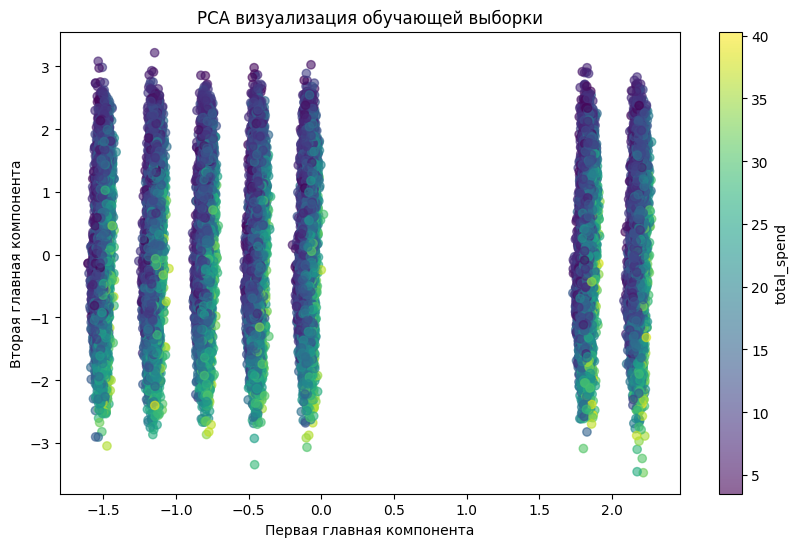

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import joblib

SEED = 42
np.random.seed(SEED)

# Загрузка сплитов
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Типы колонок
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Препроцессор без масштабирования
preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(drop='first'))]), categorical_cols)
])

# Преобразуем обучающую выборку
X_train_transformed = preprocessor.fit_transform(X_train)
print("Размерность после OHE:", X_train_transformed.shape[1])

# Применим PCA (сохраним 95% дисперсии)
pca = PCA(n_components=0.95, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_transformed)
X_val_pca = pca.transform(preprocessor.transform(X_val))
X_test_pca = pca.transform(preprocessor.transform(X_test))

print(f"Размерность после PCA: {X_train_pca.shape[1]}")

# Обучим RandomForest на PCA-признаках
rf_pca = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
y_pred_val_pca = rf_pca.predict(X_val_pca)
r2_val = r2_score(y_val, y_pred_val_pca)
mae_val = mean_absolute_error(y_val, y_pred_val_pca)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val_pca))
print(f"RandomForest + PCA (val): R² = {r2_val:.4f}, MAE = {mae_val:.2f}, RMSE = {rmse_val:.2f}")

# Сравнение с оригинальным RF (без PCA) – загрузим ранее обученный
original_rf = joblib.load('../models/randomforest_model.pkl')
y_pred_val_orig = original_rf.predict(X_val)
r2_orig = r2_score(y_val, y_pred_val_orig)
print(f"Оригинальный RF (val): R² = {r2_orig:.4f}")

# Визуализация первых двух главных компонент
plt.figure(figsize=(10,6))
scatter = plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='total_spend')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('PCA визуализация обучающей выборки')
plt.savefig('../presentation/pca_visualization.png')
plt.show()
